In [1]:
using LinearAlgebra, Statistics
using CSV, DataFrames, JLD2
using QuantumOptics
using CairoMakie
include("src/NonHermitianRydbergAtomArray.jl")
using .NonHermitianRydbergAtomArray

# Figure 1 (A) & S6

## Many-Body Complex-Energy Spectrum

Construct the full 10-atom dipolar model and diagonalize its non-Hermitian Hamiltonian over a logarithmic interaction sweep. The normalized imaginary eigenenergies are saved for the spectral PT-symmetry-breaking analysis in Figure 1(A) and Figure S6.

In [4]:
Na = 10
Γ = 1.0
Ω = 1.2Γ
V_ratios = 10 .^ collect(-2:0.01:1)

model = build_model(Na=Na, interaction=:C3, sector=:full_hilbert)
im_E = zeros(2^Na, length(V_ratios))

for (i, Vr) in enumerate(V_ratios)
    H = model.H(Ω, Vr * Γ, Γ)
    im_E[:, i] = sort(imag.(eigvals(Matrix(H.data))), rev=true) ./ Γ
end
jldsave("data/complex_spectrum.jld2";
    Na=Na, Γ=Γ, Ω=Ω, V_ratios=V_ratios, im_E=im_E)


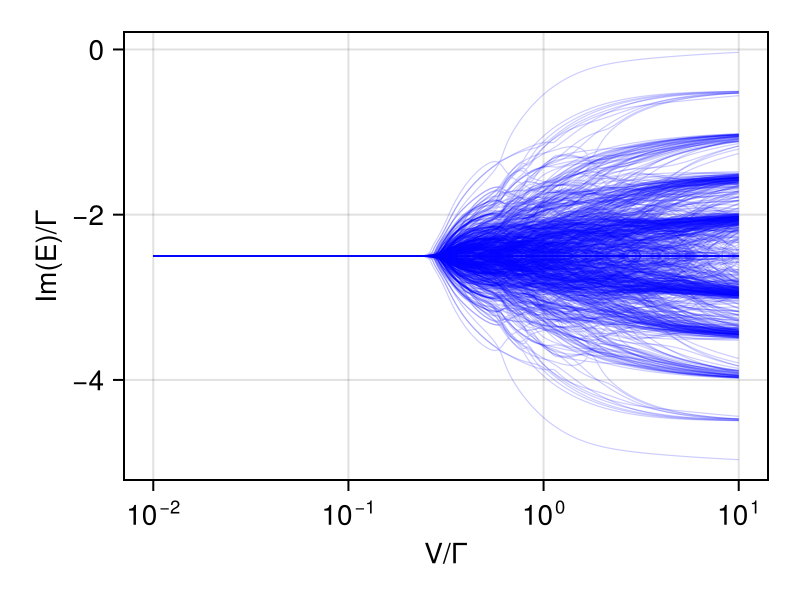

In [3]:
using JLD2, CairoMakie

data = load("data/complex_spectrum.jld2")
V_ratios = data["V_ratios"]
im_E = data["im_E"]

fig = Figure(size=(400, 300))
ax = Axis(fig[1, 1], xlabel="V/Γ", ylabel="Im(E)/Γ", xscale=log10)

for i in axes(im_E, 1)
    lines!(ax, V_ratios, im_E[i, :], color=(:blue, 0.2), linewidth=0.6)
end

fig

# Figure 2 (A,B) & S5

## Two-Atom Eigenenergy Branches

Diagonalize the two-atom Hamiltonian while varying $\Omega/\Gamma$ for three interaction strengths. Plotting both $\operatorname{Re}(E)$ and $\operatorname{Im}(E)$ shows how dipolar interactions lift degeneracies and shift the exceptional point in Figure 2(A,B) and Figure S5.

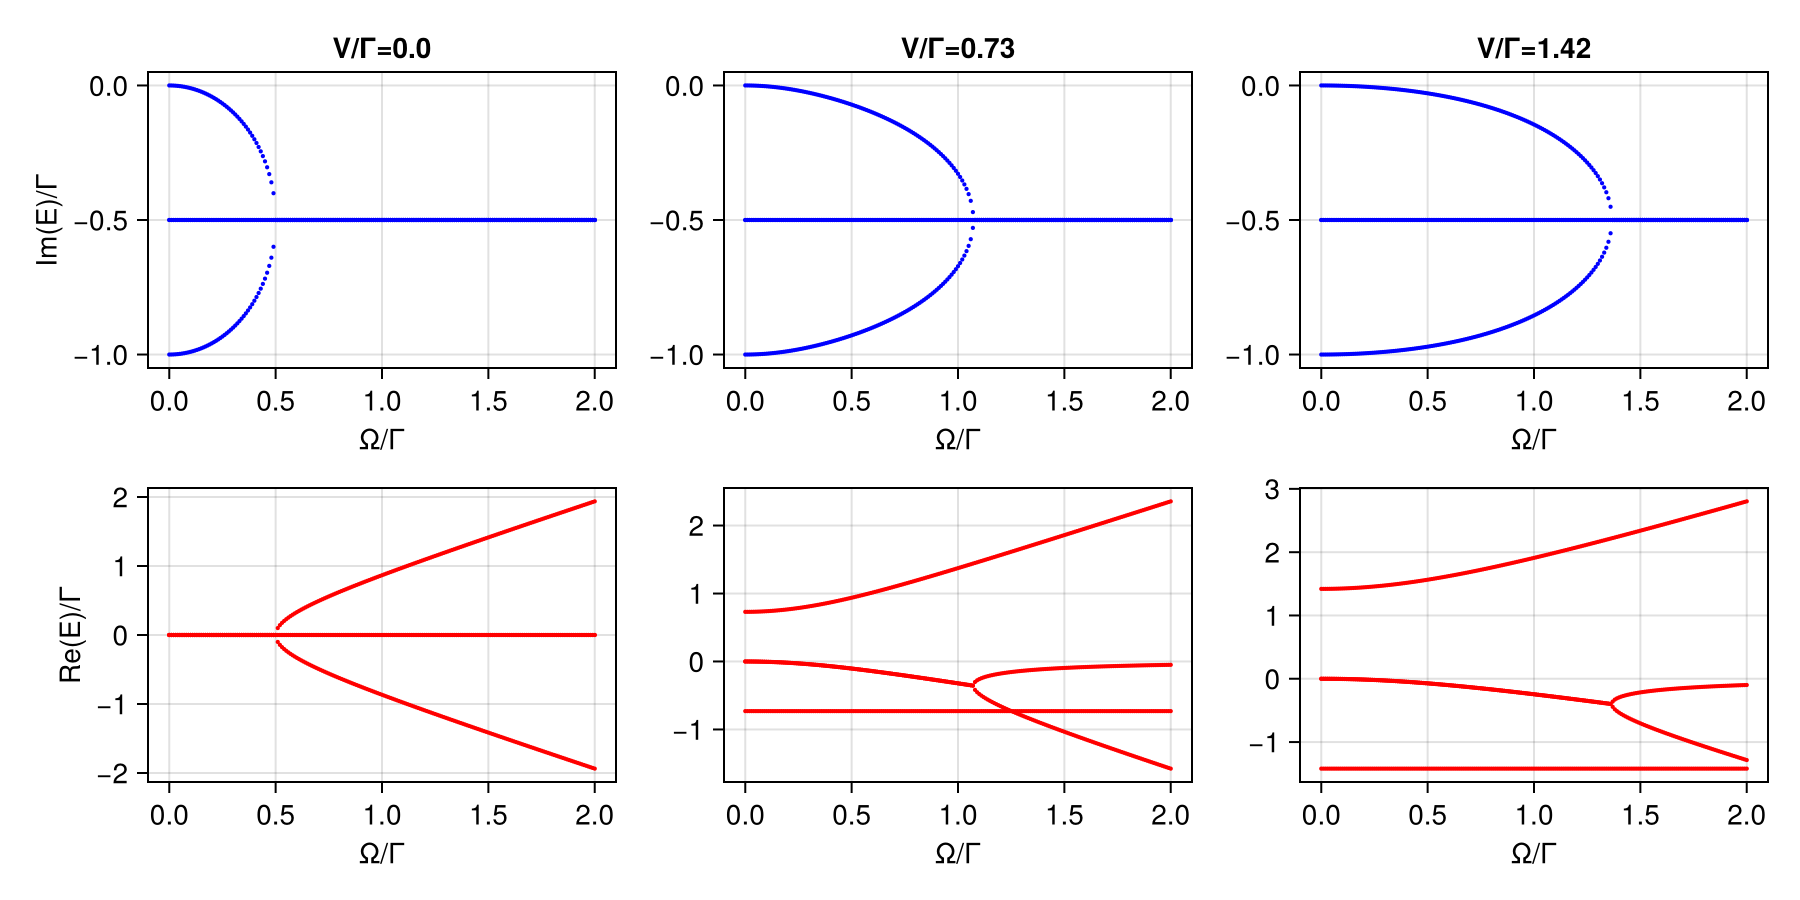

In [26]:
Γ = 2π * 3.0
Ω_ratios = 1e-8 .+ collect( 0:0.01:2)
V_ratios = [0.0, 0.73, 1.42]

fig = Figure(size=(900, 450))
for (iV, Vr) in enumerate(V_ratios)
    model = build_model(Na=2, interaction=:C3, sector=:full_hilbert)

    evals_by_Ω = [
        eigvals(Matrix(model.H(Ωr * Γ, Vr * Γ, Γ).data)) ./ Γ
        for Ωr in Ω_ratios
    ]

    ax_im = Axis(fig[1, iV], xlabel="Ω/Γ", ylabel=iV == 1 ? "Im(E)/Γ" : "",
                 title="V/Γ=$(Vr)")
    ax_re = Axis(fig[2, iV], xlabel="Ω/Γ", ylabel=iV == 1 ? "Re(E)/Γ" : "")

    for branch in 1:length(evals_by_Ω[1])
        scatter!(ax_im, Ω_ratios, [imag(e[branch]) for e in evals_by_Ω], markersize=3, color=:blue)
        scatter!(ax_re, Ω_ratios, [real(e[branch]) for e in evals_by_Ω], markersize=3, color=:red)
    end
end
fig

# Figure S14 (D)

## Multi-Atom Spin-Wave Levels

Calculate the single-excitation spin-wave energies for chains of $N=2$–$12$ atoms using nearest-neighbor and full dipolar interactions. Their different level shifts identify the near-resonant modes responsible for the system-size dependence in Figure S14(D).

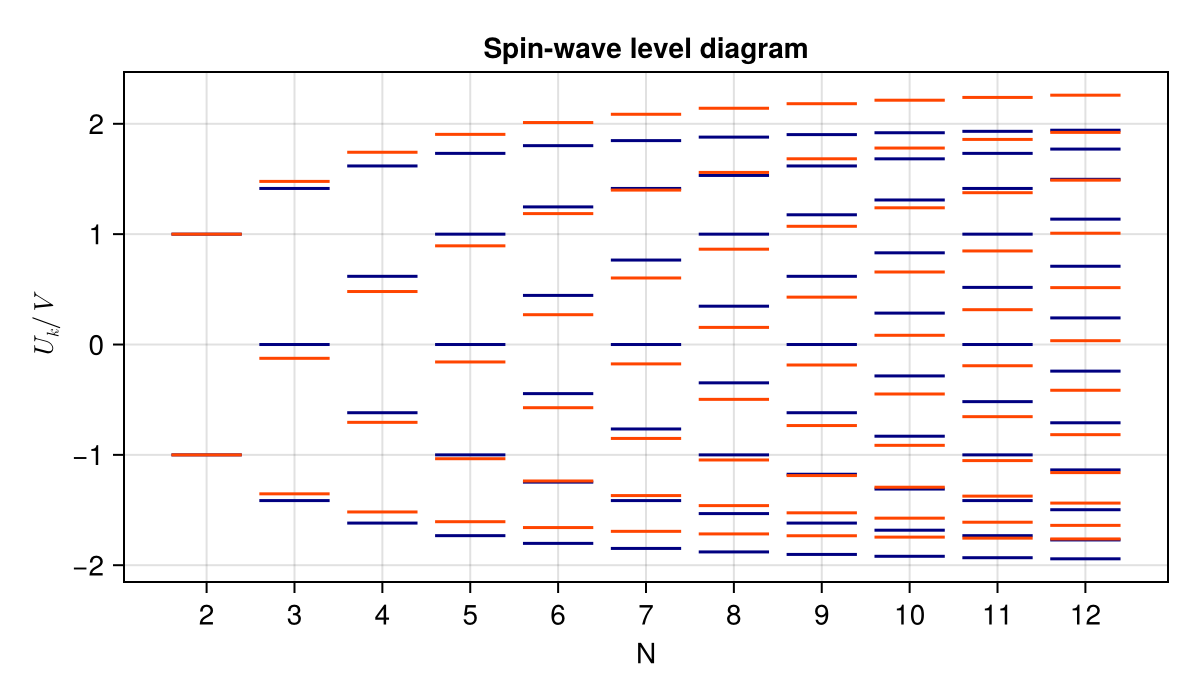

In [ ]:
Γ = 1.0
Ω = 1.2Γ
V = 4.1Γ
Ns = 2:12

fig = Figure(size=(600, 350))
ax = Axis(fig[1, 1], xlabel="N", ylabel=L"U_k / V", title="Spin-wave level diagram", xticks=1:1:12)

for Na in Ns
    H_nn, _ = ground_single_sector_nh_nn(Na, Ω, V, Γ)
    H_full, _ = ground_single_sector_nh(Na, Ω, V, Γ)

    evals_nn = eigen(H_nn[2:end, 2:end]).values ./ V
    evals_full = eigen(H_full[2:end, 2:end]).values ./ V
    
    for l in evals_nn
        lines!(ax, [Na-0.4, Na+0.4], real.(l) * [1,1], color=:navy)
    end
    for l in evals_full
        lines!(ax, [Na-0.4, Na+0.4], real.(l) * [1,1], color=:orangered)
    end
end
fig